In [4]:
import os # importing os
os.getcwd()  #getting current directory

'd:\\ABHI-VSCODE\\19.CAPSTONE-PROJECT DEPLOYMENT\\DIBETIC PREDICTION'

In [6]:
os.chdir(os.path.dirname(r'D:\ABHI-VSCODE\19.CAPSTONE-PROJECT DEPLOYMENT\DIBETIC PREDICTION\diabetes_prediction_dataset.csv'))

In [8]:
!pip install numpy pandas matplotlib seaborn scikit-learn xgboost


   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.5/69.5 MB 535.0 kB/s eta 0:02:09
   ---------------------------------------- 0.5/69.5 MB 535.0 kB/s eta 0:02:09
   ---------------------------------------- 0.8/69.5 MB 560.6 kB/s eta 0:02:03
   ---------------------------------------- 0.8/69.5 MB 560.6 kB/s eta 0:02:03
    --------------------------------------- 1.0/69.5 MB 619.7 kB/s eta 0:01:51
    --------------------------------------- 1.3/69.5 MB 687.0 kB/s eta 0:01:40
    --------------------------------------- 1.6/69.5 MB 757.3 kB/s eta 0:01:30
   - -------------------------------------- 1.8/69.5 MB 809.3 kB/s eta 0:01:24
   - -------------


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import numpy as np 

import pandas as pd #excellent for dataset manupalation

# for data visulization
import matplotlib.pyplot as plt

#stats visualization
import seaborn as sns

#Labelencoding to convert categorical data into lowlevel language
from sklearn.preprocessing import LabelEncoder

#scaling data
from sklearn.preprocessing import StandardScaler

#data partions
from sklearn.model_selection import train_test_split

#algorithams
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier


#accuracy confusion matric and classification report
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report


import warnings

# To ignore all warnings
warnings.filterwarnings("ignore")

In [4]:
#!pip install xgboost

In [10]:
df=pd.read_csv("diabetes_prediction_dataset.csv")   #Reading csv file

In [11]:
df.head() #it displace the first 5 rows

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [12]:
df.isna().any() #checking is there any null values

gender                 False
age                    False
hypertension           False
heart_disease          False
smoking_history        False
bmi                    False
HbA1c_level            False
blood_glucose_level    False
diabetes               False
dtype: bool

In [13]:
df.corr(numeric_only=True) #correlation 

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
age,1.000000,0.251171,0.233354,0.337396,0.101354,0.110672,0.258008
hypertension,0.251171,1.000000,0.121262,0.147666,0.080939,0.084429,0.197823
heart_disease,0.233354,0.121262,1.000000,0.061198,0.067589,0.070066,0.171727
bmi,0.337396,0.147666,0.061198,1.000000,0.082997,0.091261,0.214357
HbA1c_level,0.101354,0.080939,0.067589,0.082997,1.000000,0.166733,0.400660
blood_glucose_level,0.110672,0.084429,0.070066,0.091261,0.166733,1.000000,0.419558
diabetes,0.258008,0.197823,0.171727,0.214357,0.400660,0.419558,1.000000


In [14]:
df.shape #shape of the dataframe

(100000, 9)

Checking all unique elements

In [15]:
for column in df.columns: # itreating each column in df.columns 
    unique_values = df[column].unique() #finding unique values of each column

    #printing unique values
    print('Column "{}" has unique values: {}'.format(column, unique_values)) 

Column "gender" has unique values: <ArrowStringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str
Column "age" has unique values: [80.   54.   28.   36.   76.   20.   44.   79.   42.   32.   53.   78.
 67.   15.   37.   40.    5.   69.   72.    4.   30.   45.   43.   50.
 41.   26.   34.   73.   77.   66.   29.   60.   38.    3.   57.   74.
 19.   46.   21.   59.   27.   13.   56.    2.    7.   11.    6.   55.
  9.   62.   47.   12.   68.   75.   22.   58.   18.   24.   17.   25.
  0.08 33.   16.   61.   31.    8.   49.   39.   65.   14.   70.    0.56
 48.   51.   71.    0.88 64.   63.   52.    0.16 10.   35.   23.    0.64
  1.16  1.64  0.72  1.88  1.32  0.8   1.24  1.    1.8   0.48  1.56  1.08
  0.24  1.4   0.4   0.32  1.72  1.48]
Column "hypertension" has unique values: [0 1]
Column "heart_disease" has unique values: [1 0]
Column "smoking_history" has unique values: <ArrowStringArray>
['never', 'No Info', 'current', 'former', 'ever', 'not current']
Length: 6, dtype: str
Column 

In [16]:
df["smoking_history"].value_counts() #Value count of smoking _history parameter it has no info parameter

smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64

In [17]:
df["smoking_history"].value_counts()/len(df) #finding the percentage

smoking_history
No Info        0.35816
never          0.35095
former         0.09352
current        0.09286
not current    0.06447
ever           0.04004
Name: count, dtype: float64

In [18]:

# Replaceing No Info columns with pd.NA
df['smoking_history'] = df['smoking_history'].replace('No Info', pd.NA)

# Replace missing values with the mode it is string so we are using mode
mode_value = df['smoking_history'].mode()[0]
df['smoking_history'] = df['smoking_history'].fillna(mode_value) #filling no info values 

# Printing the updated value counts
print(df['smoking_history'].value_counts())


smoking_history
never          70911
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64


In [19]:
df.info() #information of the dataframe

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 7.9 MB


In [20]:
df.gender.value_counts() #Gender value_counts

gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64

In [21]:
df.describe() #descripation 

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [22]:
#removing , in bmi parameter 
df["bmi"] = [float(str(i).replace(",", "")) for i in df["bmi"]] 

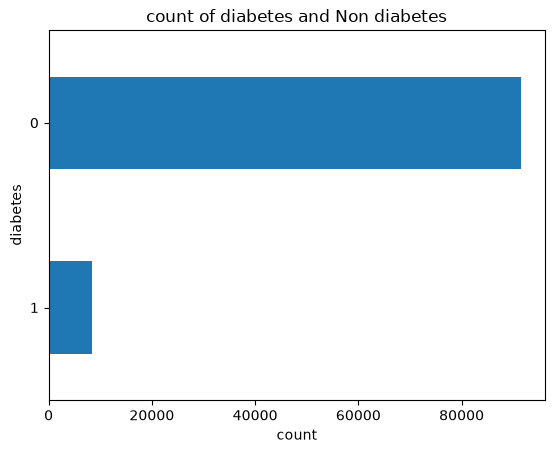

In [23]:
#ploting value_counts of diabetes in graphical representation
df['diabetes'].value_counts().plot(kind='barh') 

#Xlabel name
plt.xlabel('count')

#ylabel name
plt.ylabel('diabetes')

#title of the plot
plt.title('count of diabetes and Non diabetes')

#invert ylabes to no diabetes on top
plt.gca().invert_yaxis() 

#printing the plot
plt.show()

In [24]:
df['diabetes'].value_counts()/len(df) #percentage of 1--diabetes and 2--no diabetes 

diabetes
0    0.915
1    0.085
Name: count, dtype: float64

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [25]:
le=LabelEncoder() #activating label encoder function

le

LabelEncoder()

In [26]:
Label_encod_columns=['gender','smoking_history']  #selecting columns to apply labelencoder in next step

df[Label_encod_columns]=df[Label_encod_columns].apply(le.fit_transform) #applying label encoding

In [27]:
df.head(3) # printing top 3 columns to confirm to check labelencoder 

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,3,25.19,6.6,140,0
1,0,54.0,0,0,3,27.32,6.6,80,0
2,1,28.0,0,0,3,27.32,5.7,158,0


<Axes: >

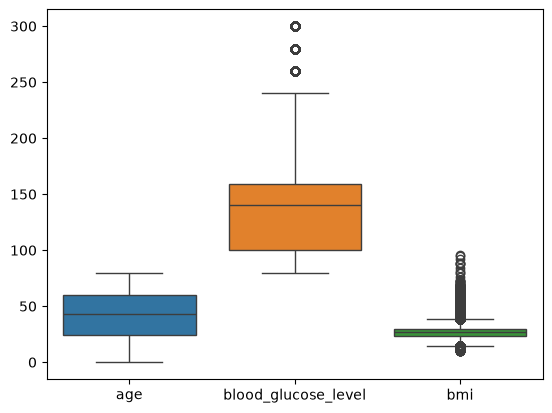

In [28]:
sns.boxplot(data=df[['age','blood_glucose_level','bmi']]) #checking outliers using boxplot

<Axes: ylabel='HbA1c_level'>

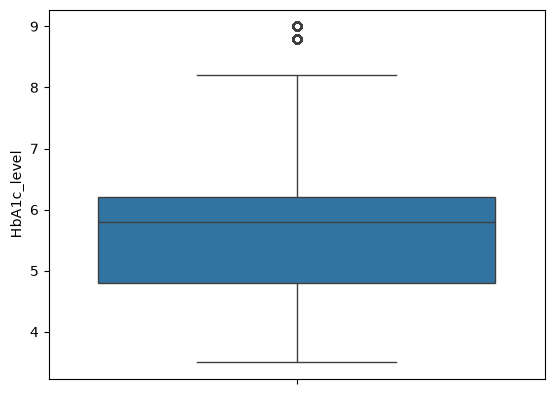

In [29]:
sns.boxplot(data=df['HbA1c_level']) #checking outlayers using boxplot

In [30]:
''' it is always good to ignore outliers in medical data '''

' it is always good to ignore outliers in medical data '

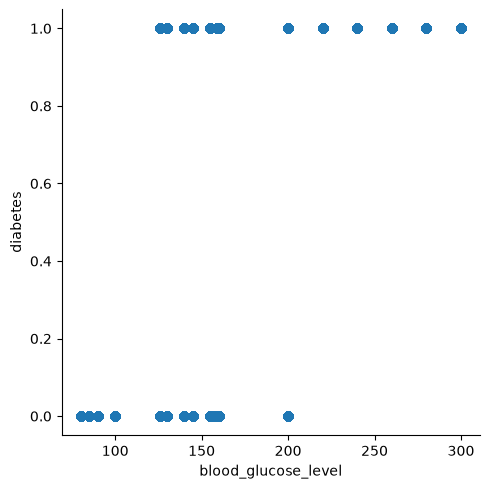

In [31]:
sns.lmplot(data=df, x='blood_glucose_level', y='diabetes', fit_reg=False)#implot plot

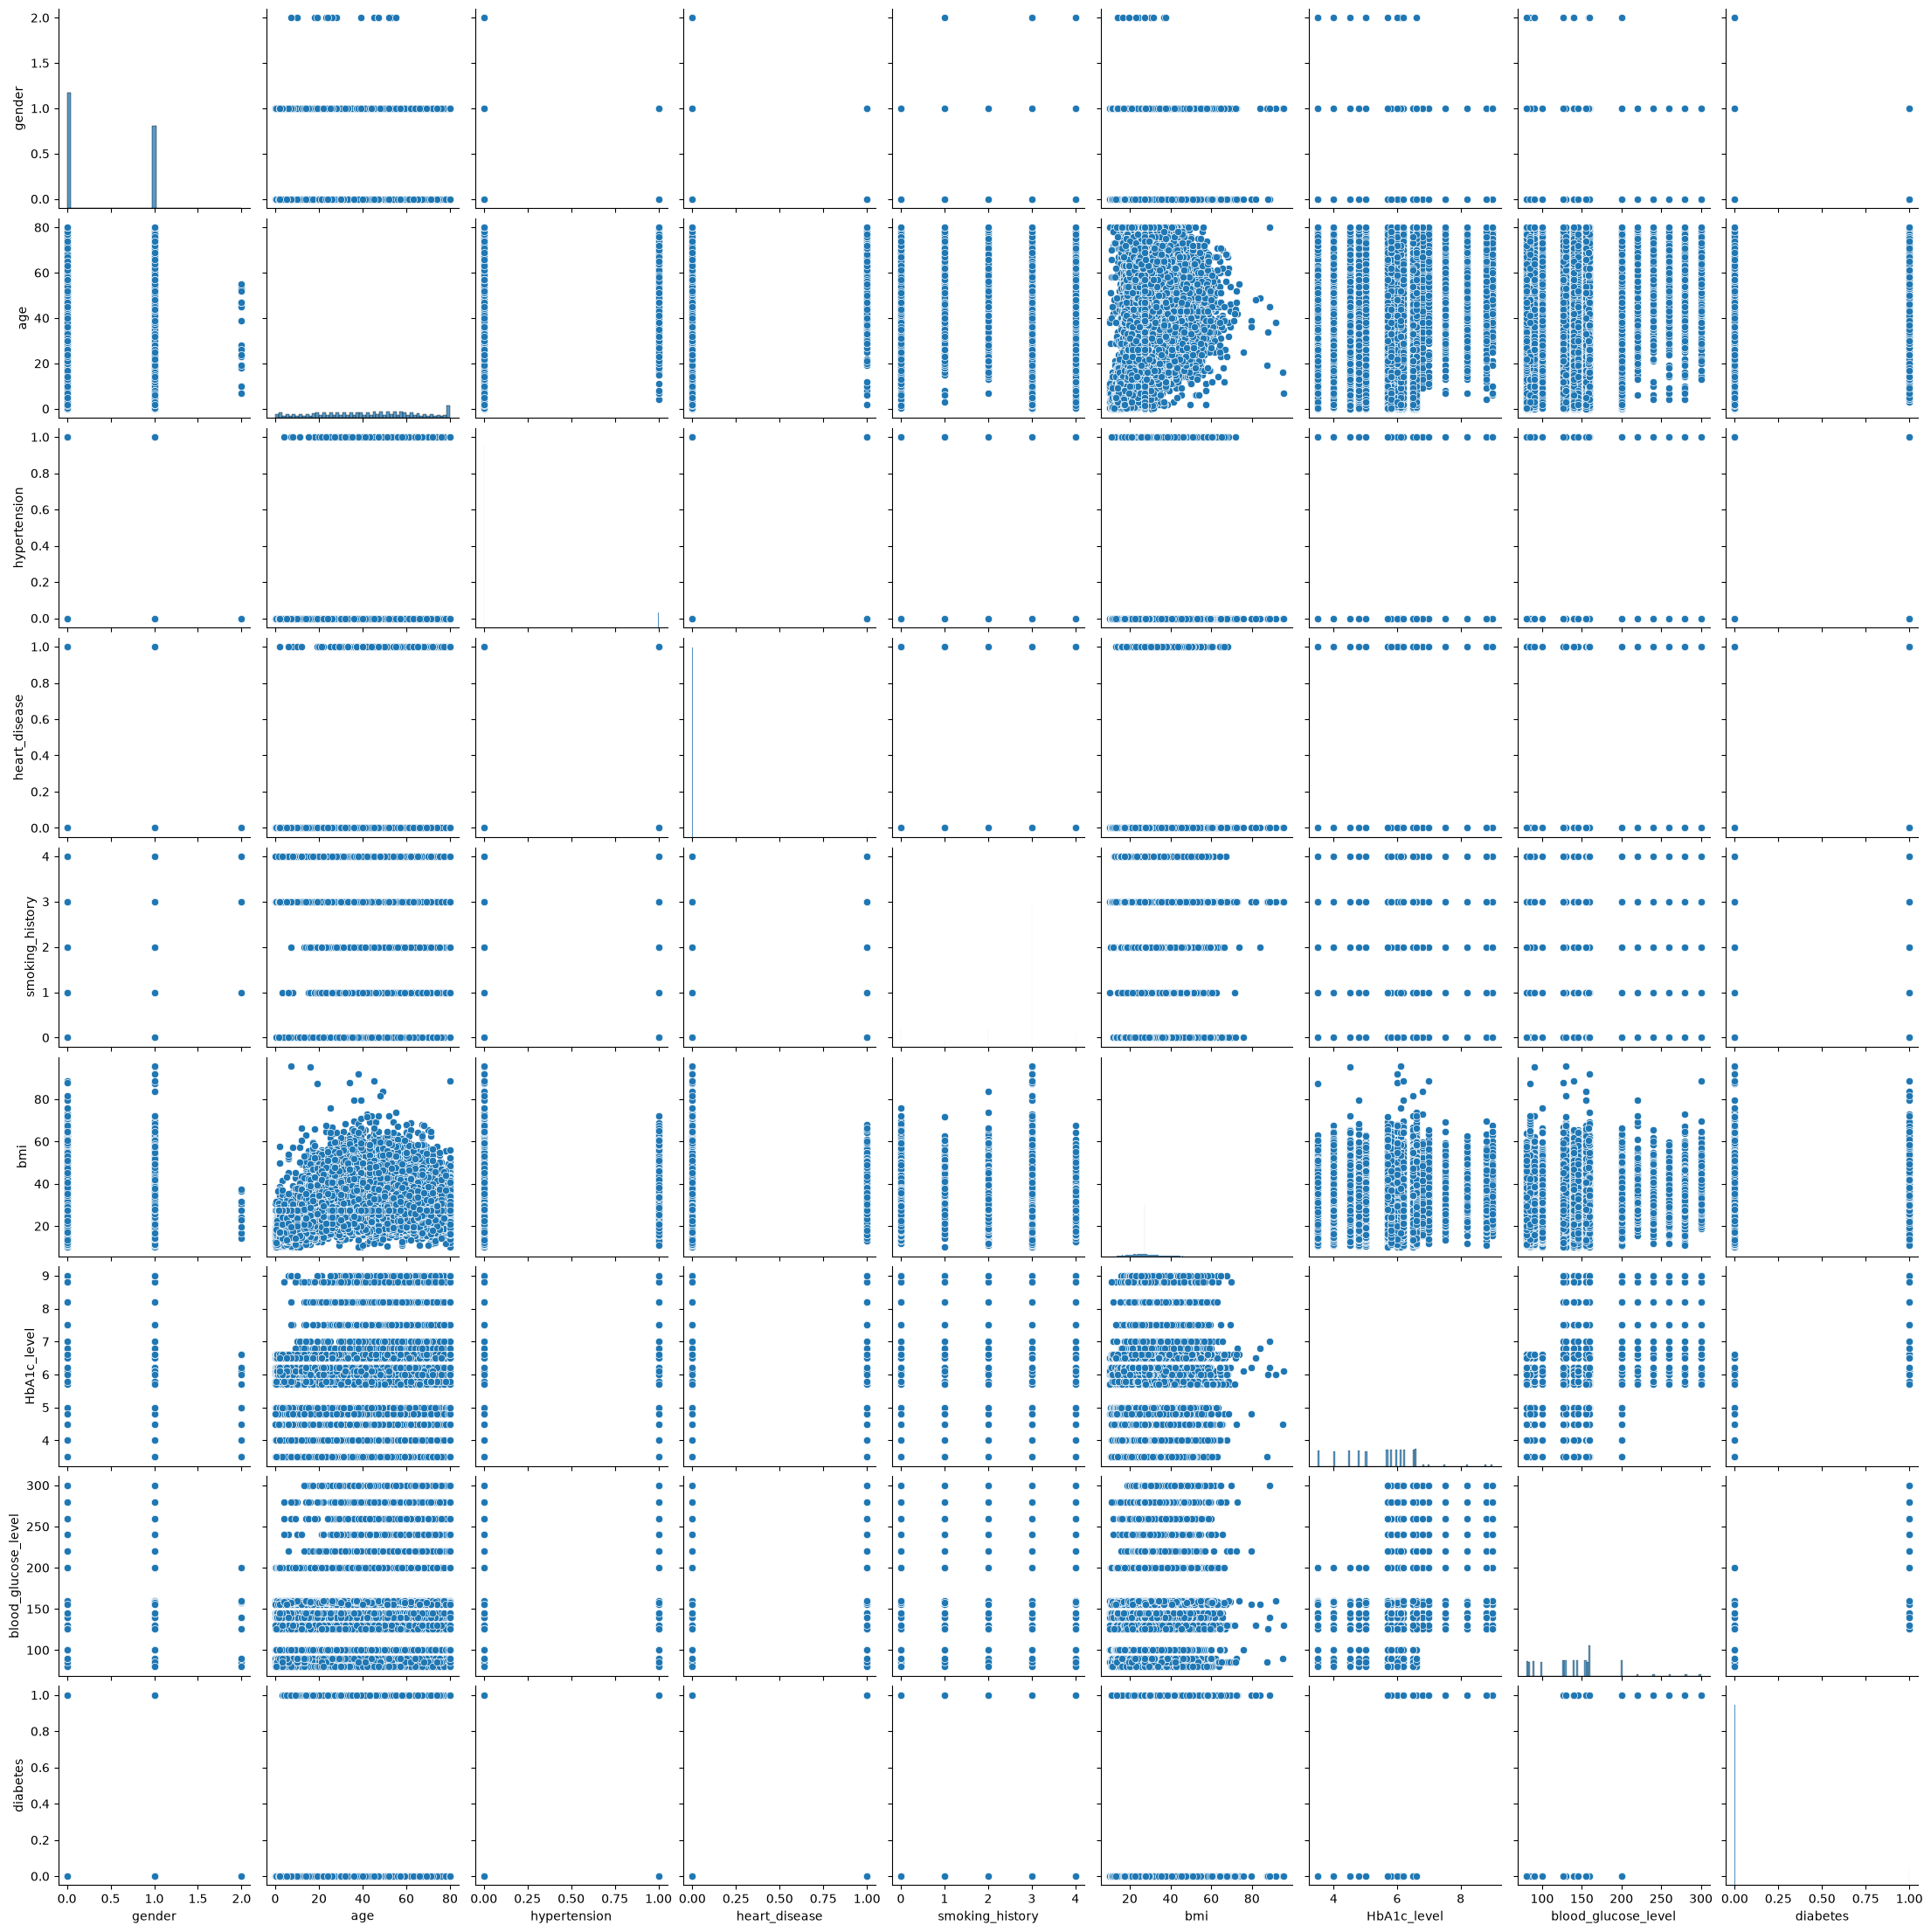

In [32]:
sns.pairplot(df) #using pairplot to check relation between parameters

#print the pairplot
plt.show()

In [33]:
'''when age increase hypertension and hert disease ,blood_glucose_level and diabetes and age  and also the is a 
   relationship between them

    *bmi
    
    *HbA1c_level
    
    *blood_glucose_level
    
    these four paramers have relationship between each other
    
    *gender and smokling history it doesnot effect on diabetes

'''

'when age increase hypertension and hert disease ,blood_glucose_level and diabetes and age  and also the is a \n   relationship between them\n\n    *bmi\n\n    *HbA1c_level\n\n    *blood_glucose_level\n\n    these four paramers have relationship between each other\n\n    *gender and smokling history it doesnot effect on diabetes\n\n'

In [34]:
df.corr()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
gender,1.000000,-0.030656,0.014203,0.077696,-0.044081,-0.022994,0.019957,0.017199,0.037411
age,-0.030656,1.000000,0.251171,0.233354,-0.098969,0.337396,0.101354,0.110672,0.258008
hypertension,0.014203,0.251171,1.000000,0.121262,-0.048631,0.147666,0.080939,0.084429,0.197823
heart_disease,0.077696,0.233354,0.121262,1.000000,-0.048253,0.061198,0.067589,0.070066,0.171727
smoking_history,-0.044081,-0.098969,-0.048631,-0.048253,1.000000,-0.087735,-0.017534,-0.022985,-0.049841
bmi,-0.022994,0.337396,0.147666,0.061198,-0.087735,1.000000,0.082997,0.091261,0.214357
HbA1c_level,0.019957,0.101354,0.080939,0.067589,-0.017534,0.082997,1.000000,0.166733,0.400660
blood_glucose_level,0.017199,0.110672,0.084429,0.070066,-0.022985,0.091261,0.166733,1.000000,0.419558
diabetes,0.037411,0.258008,0.197823,0.171727,-0.049841,0.214357,0.400660,0.419558,1.000000


<Axes: >

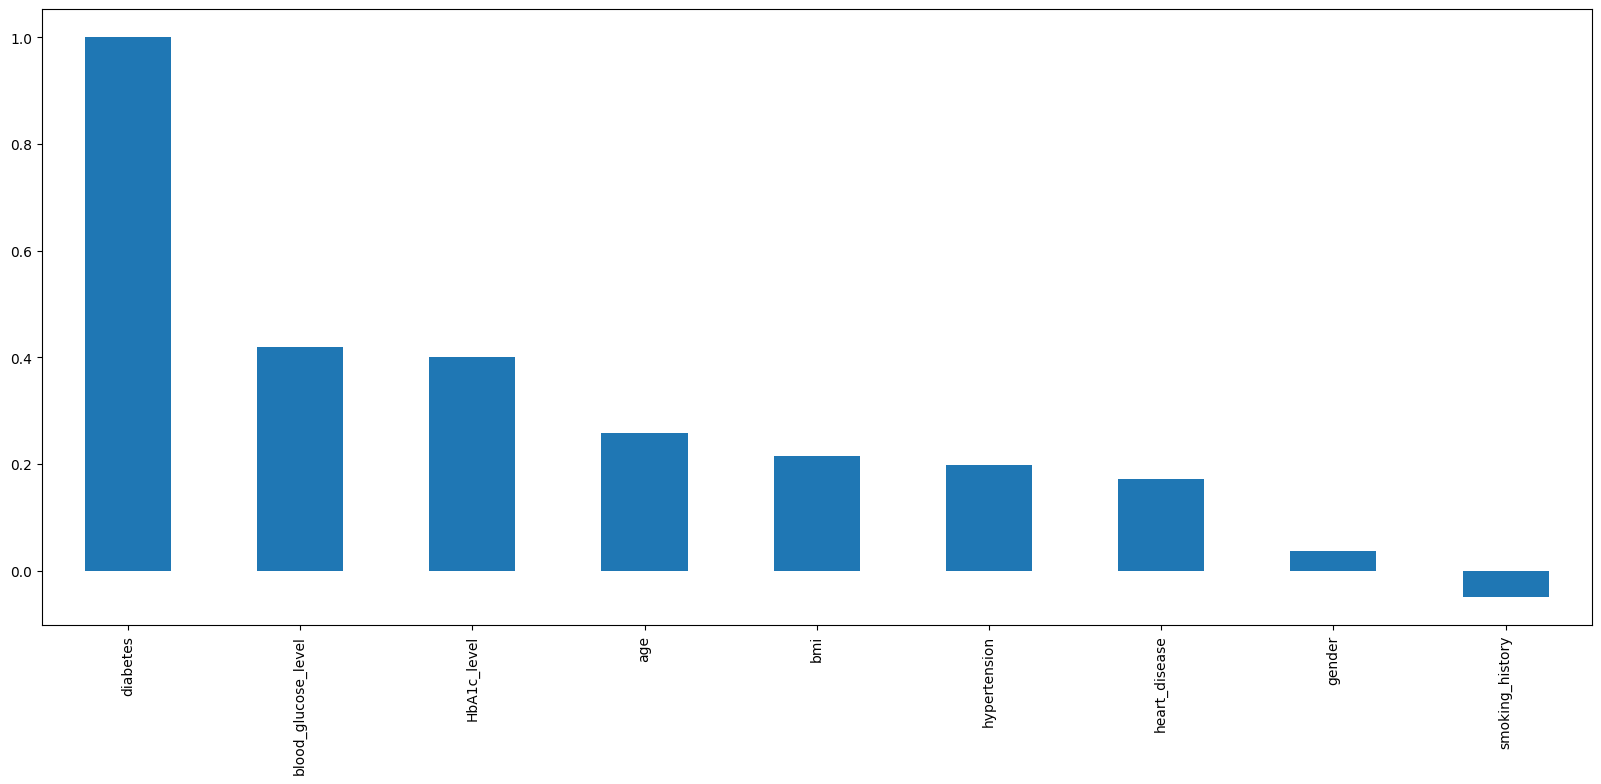

In [31]:
plt.figure(figsize=(20,8)) #figsize

#printing graphical representations of
df.corr()['diabetes'].sort_values(ascending=False).plot(kind='bar')

In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  int64  
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  int64  
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(6)
memory usage: 6.9 MB


In [36]:

#selecting X variables
X = df.loc[:, 'age':'heart_disease'].join(df.loc[:, 'bmi':'blood_glucose_level']) 


X

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level
0,80.0,0,1,25.19,6.6,140
1,54.0,0,0,27.32,6.6,80
2,28.0,0,0,27.32,5.7,158
3,36.0,0,0,23.45,5.0,155
4,76.0,1,1,20.14,4.8,155
...,...,...,...,...,...,...
99995,80.0,0,0,27.32,6.2,90
99996,2.0,0,0,17.37,6.5,100
99997,66.0,0,0,27.83,5.7,155
99998,24.0,0,0,35.42,4.0,100


In [37]:
y=df.loc[:,'diabetes']  #y variable

y #printing y variable

0        0
1        0
2        0
3        0
4        0
        ..
99995    0
99996    0
99997    0
99998    0
99999    0
Name: diabetes, Length: 100000, dtype: int64

Data partision

In [38]:
# spliting trining and testing data in 70 30 rating testing size is 0.3 random_state=42

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

In [39]:
X_train.head() #printing X_train data

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level
10382,2.0,0,0,16.45,6.2,159
73171,55.0,0,0,24.59,6.0,130
30938,24.0,0,0,21.77,4.5,130
99310,30.0,0,0,27.32,6.2,159
58959,13.0,0,0,18.37,6.5,130


In [40]:
print('Shape of Train data')

print(X_train.shape)

print(y_train.shape)

print('Shape of Testing data')

print(X_test.shape)

print(y_test.shape)

Shape of Train data
(80000, 6)
(80000,)
Shape of Testing data
(20000, 6)
(20000,)


In [41]:
ss=StandardScaler() #activating StandardScaler()

ss

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [42]:
X_train_scaled=ss.fit_transform(X_train) #scaling X_train data

In [43]:
if len(X_test.shape) == 1:   #if x is 1d array
    X_test = X_test.values.reshape(-1, 1) #converting to 2d array

X_test_scaled = ss.fit_transform(X_test) #scaling X_test data

In [44]:
model_lr=LogisticRegression()  #activating logistic Regression


In [45]:
model_lr.fit(X_train_scaled,y_train) #training logistic regression model

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [46]:
y_pred=model_lr.predict(X_test_scaled) #predecting y_test data
y_pred[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [47]:
y_test[:10] # actual y_test data

3582     0
60498    0
53227    0
21333    0
3885     0
51521    0
84261    0
10685    1
59948    0
41032    0
Name: diabetes, dtype: int64

In [45]:
accuracy_score(y_pred,y_test) #accuracy_score

0.95975

In [48]:
print(classification_report(y_pred,y_test)) #classifiaction_report

              precision    recall  f1-score   support

           0       0.99      0.97      0.98     18736
           1       0.63      0.86      0.73      1264

    accuracy                           0.96     20000
   macro avg       0.81      0.91      0.85     20000
weighted avg       0.97      0.96      0.96     20000



''' As you can see that the accuracy is quite low, and as it's an imbalanced dataset, we shouldn't consider Accuracy as our metrics to measure the model, as Accuracy is cursed in imbalanced datasets.
Hence, we need to check recall, precision & f1 score for the minority class, and it's quite evident that the precision, recall & f1 score is too low for Class 1, i.e. churned customers.
Hence, moving ahead to call SMOTEENN (UpSampling + ENN)'''


'''main advantage of using SMOTEENN is that it addresses both overfitting and underfitting issues that can arise from class imbalance. By generating synthetic samples and removing noisy ones'''


In [49]:
confusion_matrix(y_pred,y_test) #confusion_matrix

array([[18114,   622],
       [  183,  1081]])

In [50]:
y_train.value_counts() #data is highly imblancing

diabetes
0    73203
1     6797
Name: count, dtype: int64

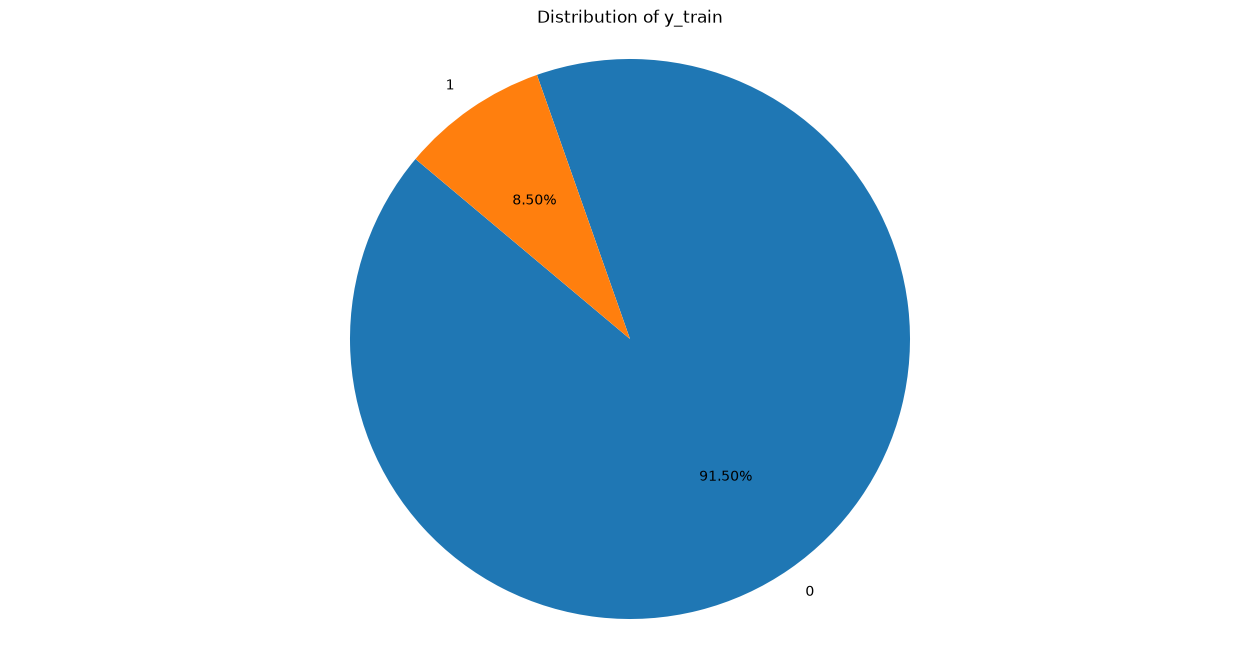

In [56]:
value_counts=y_train.value_counts()

plt.figure(figsize=(16, 8))

plt.pie(value_counts, labels=value_counts.index, autopct='%1.2f%%', startangle=140)

plt.title('Distribution of y_train')

plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

plt.show()

In [57]:
!pip install imbalanced-learn



   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


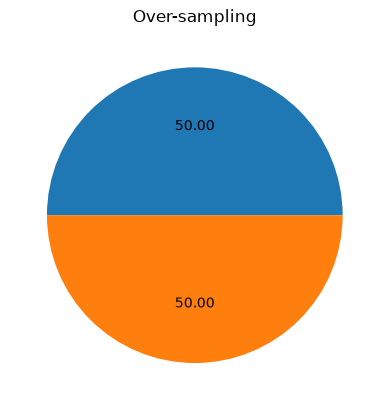

In [58]:
from imblearn.over_sampling import SMOTE # using smote function to balance our set

smote=SMOTE()

X_ovs,y_ovs=smote.fit_resample(X,y) #passing X and y variables to it to balance out data to 50 50

fig, oversp = plt.subplots() 

oversp.pie( y_ovs.value_counts(), autopct='%.2f')

oversp.set_title("Over-sampling")

plt.show()

In [59]:
# Dividing our resampling data into 70 30 ratio

Xr_train,Xr_test,yr_train,yr_test=train_test_split(X_ovs,y_ovs,train_size=0.7,random_state=42)

In [60]:
print('train data shape')

print(Xr_train.shape)

print(yr_train.shape)

print('test data shape')

print(Xr_test.shape)

print(yr_test.shape)

train data shape
(128099, 6)
(128099,)
test data shape
(54901, 6)
(54901,)


In [61]:
print('y_train and y_test value_count')
print(yr_train.value_counts())
print(yr_test.value_counts())


y_train and y_test value_count
diabetes
0    64131
1    63968
Name: count, dtype: int64
diabetes
1    27532
0    27369
Name: count, dtype: int64


In [62]:
ss=StandardScaler()

ss

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [63]:
data=Xr_train,Xr_test



xr_train_sc=ss.fit_transform(Xr_train) # scaling our resampling data xr train


Xr_test_sc=ss.fit_transform(Xr_test) # scaling our resamplig xr_test data

In [64]:
Xr_train_scaled = pd.DataFrame(xr_train_sc) #Xr_train_scaled converting into the data frame

print(Xr_train_scaled.shape)
Xr_train_scaled.head()
print(yr_train.shape)

(128099, 6)
(128099,)


In [65]:
Xr_test_scaled=pd.DataFrame(Xr_test_sc) #Xr_test converting into the dataframe

print(Xr_test_scaled.shape)
Xr_test_scaled.head() 

(54901, 6)


,0,1,2,3,4,5
0,-0.402436,-0.297609,-0.206483,0.565076,-0.268295,2.383101
1,-1.098691,-0.297609,-0.206483,-0.404901,0.376719,-0.063491
2,-1.470026,-0.297609,-0.206483,-0.286966,0.376719,-1.461543
3,-0.773772,3.360112,-0.206483,0.294478,0.376719,-1.374165
4,-1.377193,-0.297609,-0.206483,-0.286966,-2.156779,-1.112030


In [66]:
model_lk=LogisticRegression()  


model_lk.fit(Xr_train_scaled,yr_train)  #trining the model

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [67]:
y_pred_lr=model_lk.predict(Xr_test_scaled) #predecting yr_test data
y_pred_lr[:10]

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 1])

In [68]:
yr_test[:10]

180328    1
573       0
13494     0
93981     0
75389     0
180973    1
71021     0
19293     0
16393     0
121419    1
Name: diabetes, dtype: int64

In [69]:
#classification_report for predict value and orginal value

print(classification_report(y_pred_lr,yr_test)) 

              precision    recall  f1-score   support

           0       0.88      0.88      0.88     27376
           1       0.88      0.88      0.88     27525

    accuracy                           0.88     54901
   macro avg       0.88      0.88      0.88     54901
weighted avg       0.88      0.88      0.88     54901



after using smote function now our model is good precision , recall , f1-score, support is good we got excate results for all the matrics lets perform with other algo

In [70]:
#confusion_matrix for predict value and orginal value

confusion_matrix(y_pred_lr,yr_test) 

array([[24167,  3209],
       [ 3202, 24323]])

#### DecisionTreeClassifier

In [71]:
# activating DecisionTree Classifier
model_dtc=DecisionTreeClassifier() 

# passing xr_train_scaled, yr_train to trining the model
model_dtc.fit(Xr_train_scaled,yr_train)

model_dtc

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [72]:
y_pred_dtc=model_dtc.predict(Xr_test_scaled) # predicting yr_test data

In [73]:
# classification report for decisionTreeclassifier

print(classification_report(y_pred_dtc,yr_test))

              precision    recall  f1-score   support

           0       0.61      1.00      0.75     16642
           1       1.00      0.72      0.84     38259

    accuracy                           0.80     54901
   macro avg       0.80      0.86      0.80     54901
weighted avg       0.88      0.80      0.81     54901



In [74]:
confusion_matrix(y_pred_dtc,yr_test)

array([[16613,    29],
       [10756, 27503]])

#### RandomForestClassifier()

In [75]:
model_rfc=RandomForestClassifier() #activating the fuction

model_rfc.fit(Xr_train_scaled,yr_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [77]:
y_pred_rfc=model_rfc.predict(Xr_test_scaled)

In [78]:
print(classification_report(y_pred_rfc,yr_test))

              precision    recall  f1-score   support

           0       0.75      0.99      0.85     20737
           1       0.99      0.80      0.89     34164

    accuracy                           0.87     54901
   macro avg       0.87      0.90      0.87     54901
weighted avg       0.90      0.87      0.87     54901



In [79]:
confusion_matrix(y_pred_rfc,yr_test)

array([[20556,   181],
       [ 6813, 27351]])

#### XGBOOST

In [80]:
model_xgb=XGBClassifier()

model_xgb.fit(Xr_train_scaled,yr_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [82]:
y_pred_xgb=model_xgb.predict(Xr_test_scaled)

In [83]:
print(classification_report(y_pred_xgb,yr_test))

              precision    recall  f1-score   support

           0       0.59      1.00      0.74     16109
           1       1.00      0.71      0.83     38792

    accuracy                           0.79     54901
   macro avg       0.79      0.85      0.78     54901
weighted avg       0.88      0.79      0.80     54901



In [84]:
confusion_matrix(y_pred_xgb,yr_test)

array([[16086,    23],
       [11283, 27509]])

## finding the hyperparameter tuning and best param grid

In [85]:
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression

# Define the parameter grid to search over
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Regularization parameter
    'penalty': ['l1', 'l2']                # Penalty type
}

# Create a Logistic Regression model
logistic = LogisticRegression()

# Create a GridSearchCV object
grid_search = GridSearchCV(estimator=logistic, param_grid=param_grid, cv=10)

# Initialize an empty list to store the accuracy scores
accuracy_scores = []

# Perform cross-validation 10 times
for _ in range(10):
    # Fit the GridSearchCV object to the training data
    grid_search.fit(Xr_train_scaled, yr_train)
    
    # Get the best parameters
    best_params = grid_search.best_params_
    
    # Perform cross-validation with the best model
    cv_scores = cross_val_score(grid_search.best_estimator_, Xr_train_scaled, yr_train, cv=10)
    
    # Store the mean accuracy score
    accuracy_scores.append(cv_scores.mean())

# Print the accuracy scores obtained over 10 iterations
#print("Accuracy scores over 10 iterations:", accuracy_scores)
print("Accuracy scores over 10 iterations:", ["{:.2f}".format(score) for score in accuracy_scores])


# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best parameters found:", best_params)
print("Best cross-validation score:", best_score)


Accuracy scores over 10 iterations: ['0.89', '0.89', '0.89', '0.89', '0.89', '0.89', '0.89', '0.89', '0.89', '0.89']
Best parameters found: {'C': 0.001, 'penalty': 'l2'}
Best cross-validation score: 0.8854245584666177


## FINAL MODEL

In [86]:
from sklearn.linear_model import LogisticRegression

# Create a Logistic Regression model with the best parameters
final_model = LogisticRegression(C=0.001, penalty='l2')

# Fit the final model to the entire training dataset
final_model.fit(Xr_train_scaled, yr_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.001
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver be

In [87]:
import pickle

# Save the final model to a pickle file
with open('final_model.pkl', 'wb') as file:
    pickle.dump(final_model, file)


In [89]:
import pickle
import numpy as np

# Load the model from the pickle file
with open('final_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

# Define the mean and standard deviation of the training data
mean_values = [41.885856, 0.07485, 0.03942, 27.320767, 5.527507, 138.058060]
std_values = [22.516840, 0.26315, 0.194593, 6.636783, 1.070672, 40.708136]

# Define the input features for prediction
age = 30
hypertension = 0
heart_disease = 0
bmi = 100.0
HbA1c_level = 5.0
blood_glucose_level = 90

# Scale the input features manually
scaled_features = [(x - mean) / std for x, mean, std in zip(
    [age, hypertension, heart_disease, bmi, HbA1c_level, blood_glucose_level],
    mean_values, std_values
)]

# Make predictions on the scaled data
prediction = loaded_model.predict([scaled_features])

# Print the prediction
if prediction[0] == 1:
    print("Diabetic")
else:
    print("Not Diabetic")


Diabetic
